</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>Práctica 2: Aprendizaje y selección de modelos de clasificación
        </h2>
        <h1 style="margin-top: -10px;">
            Ejemplo en scikit-learn
        </h1>
    </div>
    <div style="width: 50%; text-align: right;">
        <div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 30px;">
            <div style="width: 20%;"></div>
            <div style="width: 80%; border-left: 2px solid #555555; padding-left: 20px;">
                <div style="margin-bottom: 20px;">
                    <p style="margin: 0; font-size: 1.4em; font-weight: bold;">
                        Minería de Datos, 2025-26
                    </p>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        José Antonio Gámez Martín
                    </span>
                    <a href="mailto:Jose.Gamez@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Jose.Gamez@uclm.es
                    </a>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        Pablo Torrijos Arenas
                    </span>
                    <a href="mailto:Pablo.Torrijos@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Pablo.Torrijos@uclm.es
                    </a>
                </div>
                </div>
            </div>
        </div>
    </div>
</div>

## 1. Introducción

En este notebook repasaremos varios algoritmos de clasificación supervisada disponibles en `scikit-learn`. Aprenderemos a evaluar su rendimiento de forma robusta utilizando **validación cruzada** y a optimizar sus **hiperparámetros** mediante **búsqueda en malla** (`GridSearchCV`).

Utilizaremos el conjunto de datos [Student Performance](https://archive.ics.uci.edu/ml/datasets/student+performance) (`student-por.csv`), que ya exploramos en el tutorial de `Pipelines` de la Práctica 1. Reutilizaremos el pipeline de preprocesamiento básico definido allí para preparar los datos antes de entrenar los diferentes modelos.

El objetivo es entender el flujo de trabajo para comparar modelos y seleccionar la mejor configuración para un problema dado.

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 2. Preparación de Datos

Cargamos las librerías necesarias y el conjunto de datos:

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)
random_state = 2025 # Fijar semilla para reproducibilidad

In [2]:
df = pd.read_csv('student-por.csv')

# Separar variables predictoras (X) y objetivo (y)
X = df.drop(columns=["target"])
y = df["target"]

X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0


### 2.1 Pipeline de Preprocesamiento Básico

Reutilizamos el `ColumnTransformer` del tutorial anterior para aplicar imputación y escalado a variables numéricas, e imputación y codificación `OneHot` a las categóricas:

**Nota:** Por claridad, si en vuestro `Pipeline` para la Práctica 2 contáis con una gran cantidad de funciones o clases personalizadas (como esta `discretize_age()`) podéis guardarlas en un archivo `utils.py` e importarlas.

In [3]:
def discretize_age(df):
    """Discretizes the 'age' column into groups and drops the original."""
    df_copy = df.copy()
    if "age" in df_copy.columns:
        df_copy["age_group"] = pd.cut(
            df_copy["age"],
            bins=[0, 17, 20, np.inf],
            labels=["Adolescente", "Joven", "Adulto"],
            right=True # Includes the right edge (e.g., 17 is Adolescente)
        )
        df_copy = df_copy.drop(columns=["age"])
    return df_copy

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

# Identificar columnas numéricas y categóricas (una vez sabemos que 'age' se va a discretizar)
num_cols_after_discretize = X.select_dtypes(include=np.number).columns.drop('age').tolist()
cat_cols_after_discretize = X.select_dtypes(exclude=np.number).columns.tolist() + ['age_group'] 

print("Variables numéricas:", num_cols_after_discretize)
print("Variables categóricas:", cat_cols_after_discretize)

# Transformador personalizado para discretizar la edad
age_discretizer = FunctionTransformer(discretize_age, validate=False) # validate=False allows pandas DataFrame input/output

# Pipeline para columnas numéricas
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para columnas categóricas
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combinar en ColumnTransformer
column_transformer = ColumnTransformer([
    ("num", num_pipe, num_cols_after_discretize),
    ("cat", cat_pipe, cat_cols_after_discretize)
], remainder='passthrough') # 'passthrough' por si alguna columna no es ni num ni cat

preprocessor = Pipeline([
    ('age_discretizer', age_discretizer),
    ('column_transformer', column_transformer)
])
preprocessor

Variables numéricas: ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Variables categóricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'age_group']


Pipeline(steps=[('age_discretizer',
                 FunctionTransformer(func=<function discretize_age at 0x000002C6E989D6C0>)),
                ('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Medu', 'Fedu', 'traveltime',
                                                   'studytime', 'failures',
                                                   'famrel', 'freeti...
                                                   'goout', 'Dalc', 'Walc',
                                                   'health', 'absences']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic',
                                                   'age_group'])]))])

### 2.2 División Entrenamiento / Prueba

Dividimos los datos para tener un conjunto de prueba final no visto durante la optimización. Usaremos validación cruzada sobre el conjunto de entrenamiento.

Esta es la forma general de proceder. En vuestro caso, al contar con `uclm_student_train.csv` y `uclm_student_test.csv`, y poder subir las predicciones a Kaggle, podríais obviar este paso. Pero como bien sabéis, solo nos podemos creer el resultado final del conjunto de test si lo usamos una única vez, por lo que cuántas más subidas hagáis a Kaggle y más veces lo uséis, más riesgo tendréis de sobreajustar vuestro modelo al test público de Kaggle.

In [5]:
from sklearn.model_selection import train_test_split

# División Hold-out estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, # 30% para prueba
    stratify=y, # Mantener proporción de clases
    random_state=random_state
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

# Opcional: Probar el preprocesador
X_train_processed = preprocessor.fit_transform(X_train)
print("\nDimensiones entrenamiento tras preprocesamiento:", X_train_processed.shape)
X_test_processed = preprocessor.transform(X_test)
print("Dimensiones prueba tras preprocesamiento:", X_test_processed.shape)

Tamaño entrenamiento: (454, 30)
Tamaño prueba: (195, 30)

Dimensiones entrenamiento tras preprocesamiento: (454, 58)
Dimensiones prueba tras preprocesamiento: (195, 58)


<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 3. Modelos de Clasificación Supervisada

A continuación, introduciremos brevemente los modelos de clasificación que exploraremos en este tutorial. Para cada uno, crearemos una instancia con su configuración por defecto o una configuración básica. Más adelante, utilizaremos `GridSearchCV` para encontrar la configuración óptima de sus hiperparámetros.

### 3.1. Vecinos Más Cercanos (kNN)

Este algoritmo clasifica una instancia basándose en la clase mayoritaria de sus $k$ vecinos más cercanos en el espacio de características. Es un método basado en instancias y no paramétrico.

* **Clase:** [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
* **Hiperparámetros clave:** `n_neighbors` (número de vecinos), `weights` (cómo ponderar a los vecinos), `metric` (métrica de distancia).

In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()

### 3.2. Clasificadores Naive Bayes

Los métodos Naive Bayes aplican el **Teorema de Bayes** con la suposición "ingenua" (*naive*) de **independencia condicional** entre cada par de características, dada la clase. A pesar de esta simplificación, son algoritmos muy rápidos y eficientes, especialmente con grandes volúmenes de datos o alta dimensionalidad (ej. clasificación de texto).

`scikit-learn` ofrece distintas variantes según la distribución asumida para las características:
* [`GaussianNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html): Asume que las características continuas siguen una distribución gaussiana.
* [`CategoricalNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html): Diseñado para características categóricas (discretas).

*Nota sobre tipos de datos mixtos:* `scikit-learn` no proporciona una implementación única que maneje directamente una mezcla de características continuas y categóricas. Una solución común es transformar todas las características a un tipo compatible (ej. discretizar continuas para `CategoricalNB`, o usar `OneHotEncoder` sobre categóricas para `GaussianNB`). Como muchos recordarán de la asignatura "Sistemas Basados en el Conocimiento", implementar una versión híbrida que combine ambos enfoques es conceptualmente sencillo. **Quien lo desee**, puede integrar su propia implementación híbrida (por ejemplo, importándola desde un `utils.py`). En este tutorial, usaremos `GaussianNB` dado que nuestro pipeline preprocesa todas las características a formato numérico.

* **Clases:** [`GaussianNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html), [`CategoricalNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html)
* **Hiperparámetros Clave:** Generalmente, los modelos Naive Bayes requieren **poca optimización** de hiperparámetros.
    * `GaussianNB`: `var_smoothing` (porción de la mayor varianza añadida a las varianzas para estabilidad numérica).
    * `CategoricalNB`: `alpha` (parámetro de suavizado de Laplace).

In [7]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()  # Usamos GaussianNB ya que el preprocesador convierte todo a numérico

### 3.3. Árboles de Decisión

Construyen un modelo predictivo mediante una estructura jerárquica similar a un árbol. Partiendo de la raíz con todos los datos, se realizan **divisiones sucesivas** en los nodos internos basándose en las características que mejor separan las clases (según un `criterion` como Gini o Entropía). Las predicciones finales se encuentran en los nodos hoja.

Su principal ventaja es la **interpretabilidad**, ya que las rutas desde la raíz hasta las hojas pueden leerse como reglas de clasificación. Sin embargo, su mayor desventaja es la **tendencia al sobreajuste (overfitting)**. Si no se limita su crecimiento, los árboles pueden volverse excesivamente complejos, memorizando el ruido y los detalles específicos del conjunto de entrenamiento, lo que resulta en una **mala generalización** ante datos nuevos. Por defecto, `scikit-learn` tiende a crear árboles profundos (*fully developed*) que a menudo sufren de este problema.

Para mitigar el sobreajuste y mejorar la capacidad de generalización, es esencial controlar el tamaño y complejidad del árbol a través de hiperparámetros.

*Nota sobre variables categóricas:* Como vimos en la Práctica 1, `scikit-learn` no admite variables categóricas en los árboles de decisión, por lo que habrá que preprocesarlas previamente.

* **Clase:** [`sklearn.tree.DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
* **Hiperparámetros clave:** `criterion` (medida de calidad de la división), `max_depth` (profundidad máxima), `min_samples_split` (mínimo de muestras para dividir un nodo), `min_samples_leaf` (mínimo de muestras en una hoja), `ccp_alpha` (poda por complejidad).

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=random_state)

### 3.4. Métodos Ensemble

Los métodos *ensemble* combinan las predicciones de varios modelos base (estimadores) para obtener una predicción final más robusta y precisa que la de cualquier estimador individual. Antes de ver los algoritmos específicos, es útil entender el **compromiso sesgo-varianza**, ya que motiva las diferentes estrategias de los ensembles.

### Entendiendo el Compromiso Sesgo-Varianza

El error total de un modelo supervisado se puede descomponer conceptualmente en tres partes:
1.  **Sesgo (*Bias*):** Es el error debido a las suposiciones simplificadoras del modelo. Un modelo con **alto sesgo** es demasiado simple y no logra capturar la complejidad subyacente de los datos (**underfitting**). Por ejemplo, un árbol de decisión muy superficial (`max_depth=1`, un *stump*) probablemente tendrá un sesgo alto.
2.  **Varianza (*Variance*):** Es el error debido a la sensibilidad del modelo a pequeñas fluctuaciones en los datos de entrenamiento. Un modelo con **alta varianza** se ajusta demasiado a los datos de entrenamiento, incluyendo el ruido, y no generaliza bien a datos nuevos (**overfitting**). Por ejemplo, un árbol de decisión muy profundo (`max_depth=None`) sin regularización probablemente tendrá una varianza alta.
3.  **Error Irreducible:** Es el ruido inherente a los datos que ningún modelo puede eliminar.

Idealmente, buscamos un modelo con **bajo sesgo y baja varianza**. Sin embargo, típicamente existe un **compromiso**: reducir el sesgo suele aumentar la varianza, y viceversa. Los modelos simples tienen alto sesgo y baja varianza, mientras que los modelos complejos tienen bajo sesgo y alta varianza. 

<img src="img/sesgo-varianza.png" alt="Ilustración del dilema sesgo-varianza usando una analogía de tiro al blanco" width="700"/>

*Ilustración del dilema sesgo-varianza usando una analogía de tiro al blanco. Atribución: [Wikipedia](https://es.wikipedia.org/wiki/Dilema_sesgo-varianza)*

La imagen anterior ilustra este concepto: el centro de la diana representa el modelo perfecto.
* **Alto sesgo, baja varianza:** Los disparos están agrupados pero lejos del centro (el modelo es consistente pero incorrecto).
* **Alto sesgo, alta varianza:** Los disparos están dispersos y lejos del centro (el modelo es inconsistente e incorrecto).
* **Bajo sesgo, baja varianza:** Los disparos están agrupados y en el centro (ideal).
* **Bajo sesgo, alta varianza:** Los disparos están dispersos pero centrados alrededor del objetivo (el modelo acierta en promedio, pero es inconsistente).

Los ensembles atacan este problema de diferentes maneras:
* **Bagging (incluye Random Forest):** Combina en paralelo **estimadores fuertes** (*strong learners*), que son modelos con **bajo sesgo** pero **alta varianza** (como árboles de decisión profundos y sin podar). Se introduce aleatoriedad (muestreo bootstrap, subconjuntos de características) para que los estimadores sean diversos. Al promediar sus predicciones (como calcular el centroide de los disparos dispersos en la imagen "*Bajo sesgo, alta varianza*"), se **reduce la varianza** general del ensemble, acercando la predicción promedio al centro en el ejemplo.

    <img src="img/bag.jpg" alt="Ilustración del dilema sesgo-varianza usando una analogía de tiro al blanco" width="500"/>

* **Boosting:** Combina secuencialmente **estimadores débiles** (*weak learners*), que son modelos con **alto sesgo** pero **baja varianza** (como árboles con muy poca profundidad). Cada nuevo estimador se enfoca en corregir los errores (la desviación sistemática en la imagen "*Alto sesgo, baja varianza*") de los anteriores. El objetivo principal es **reducir el sesgo** del ensemble final, moviendo el grupo de disparos hacia el centro en el ejemplo.

    <img src="img/boost.jpg" alt="Ilustración del dilema sesgo-varianza usando una analogía de tiro al blanco" width="500"/>

Ahora, veamos los algoritmos específicos:

#### 3.4.1. Bagging (Bootstrap Aggregating)

Entrena múltiples estimadores fuertes (por defecto, `DecisionTreeClassifier()` sin restricciones) en paralelo (con el parámetro `n_jobs`). Por defecto, cada uno se entrena sobre una muestra aleatoria con reemplazo (*bootstrap*) del conjunto de entrenamiento. Las predicciones se combinan (voto mayoritario para clasificación). Busca reducir la **varianza**.

Se suele utilizar con árboles de decisión, pero es un ensemble genérico que acepta cualquier tipo de estimador. Usa 10 estimadores por defecto.

* **Clase:** [`sklearn.ensemble.BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)
* **Hiperparámetros clave:** `estimator` (estimador base), `n_estimators` (número de estimadores, por defecto 10), `max_samples` (tamaño de la muestra bootstrap), `max_features` (número de variables usadas para entrenar cada clasificador, por defecto 1.0 (todas)).

In [9]:
from sklearn.ensemble import BaggingClassifier
bagging_model = BaggingClassifier(random_state=random_state)  # Bagging usa DecisionTreeClassifier() por defecto si no se especifica 'estimator'

#### 3.4.2. Random Forest

Es una especificación de Bagging que utiliza árboles de decisión como estimadores base. Además del muestreo *bootstrap* de las instancias, introduce aleatoriedad al seleccionar las características (parecido al `max_features` de `BaggingClassifier`, pero aleatorizando en cada *split*, no en cada clasificador): en cada división de nodo, solo considera un subconjunto aleatorio de características (`max_features`). Esto descorrelaciona aún más los árboles, reduciendo eficazmente la **varianza**.

Los parámetros del árbol son los mismos por defecto que los de `DecisionTreeClassifier`: crea árboles lo más sobreajustado posible. En este caso, Random Forest usa 100 estimadores por defecto ya que, al no usar todas las variables en cada split, el tiempo de entrenamiento es mucho menor que un Bagging por defecto. Además, en Bagging normalmente más modelos mejoran el resultado o, al menos, no lo empeoran.

* **Clase:** [`sklearn.ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
* **Hiperparámetros clave:** `n_estimators` (por defecto 100), `criterion`, `max_depth` (por defecto `None`), `min_samples_split` (por defecto 2), `min_samples_leaf` (por defecto 1), `max_features` (por defecto `sqrt`).

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=random_state)

#### 3.4.3. AdaBoost (Adaptive Boosting)

Construye secuencialmente estimadores débiles (por defecto, `DecisionTreeClassifier(max_depth=1)`, creando "árboles" que realmente son solo una regla). En cada iteración, aumenta el peso de las instancias mal clasificadas por el ensemble hasta ese momento, obligando al siguiente estimador a centrarse en ellas. Busca reducir el **sesgo**.

Se suele utilizar con árboles de decisión, pero es un ensemble genérico que acepta cualquier tipo de estimador. Usa 50 estimadores por defecto, lo cual suele ser razonable. En este caso no siempre más es mejor, ya que después de un cierto punto el modelo puede dejar de aprender el patrón general de los datos y comenzar a modelar el ruido específico del conjunto de entrenamiento.

* **Clase:** [`sklearn.ensemble.AdaBoostClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)
* **Hiperparámetros clave:** `estimator` (estimador base), `n_estimators` (número de estimadores, por defecto 50), `learning_rate` (tasa de aprendizaje)

Se suele utilizar con árboles de decisión, pero es un ensemble genérico que acepta cualquier tipo de estimador.

In [11]:
from sklearn.ensemble import AdaBoostClassifier
adaboost_model = AdaBoostClassifier(random_state=random_state)  # AdaBoost usa DecisionTreeClassifier(max_depth=1) por defecto si no se especifica 'estimator'

#### 3.4.4. Gradient Tree Boosting

Como AdaBoost, construye estimadores (obligatoriamente árboles de decisión en `scikit-learn`) secuencialmente. Sin embargo, en lugar de ajustar los pesos de las instancias, cada nuevo árbol se entrena para predecir el **error residual** (específicamente, el gradiente negativo de la función de pérdida) del ensemble formado por los árboles anteriores. Esto permite optimizar funciones de pérdida más generales. Es un método muy potente que puede reducir tanto el **sesgo** como la **varianza** (mediante hiperparámetros de regularización).

Los árboles base suelen ser un poco más profundos que en AdaBoost (ej. `max_depth=3` por defecto), pero aún relativamente controlados. La `learning_rate` (tasa de aprendizaje o *shrinkage*) es crucial: valores más pequeños requieren más `n_estimators` pero a menudo generalizan mejor. Usa 100 estimadores por defecto.

* **Clase:** [`sklearn.ensemble.GradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
* **Hiperparámetros clave:** `loss` (función de pérdida), `learning_rate` (por defecto 0.1), `n_estimators` (por defecto 100), `max_depth` (por defecto 3), `subsample` (fracción de muestras para entrenar cada árbol, introduce *stochasticity*, reduciendo la varianza e incrementando el sesgo).

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=random_state)

#### 3.4.5. Histogram-Based Gradient Boosting

Es una implementación optimizada y mucho más rápida de Gradient Boosting, especialmente eficaz en conjuntos de datos grandes (`n_samples >= 10 000`). Su principal innovación es que **discretiza** las características continuas en un número fijo de contenedores (*bins*, por defecto (y máximo) 255) antes del entrenamiento. Esto se hace una sola vez al principio. Luego, en lugar de buscar el mejor punto de corte entre todos los valores únicos, los árboles solo necesitan considerar los límites de estos *bins*, lo que acelera enormemente la construcción utilizando estructuras basadas en histogramas.

Otra ventaja significativa es su **soporte nativo para valores faltantes**, que no requieren imputación previa. El algoritmo aprende automáticamente cómo tratar las ausencias durante el entrenamiento. Usa 100 iteraciones (estimadores) por defecto.

* **Clase:** [`sklearn.ensemble.HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)
* **Hiperparámetros clave:** `loss`, `learning_rate` (por defecto 0.1), `max_iter` (número de iteraciones/árboles, por defecto 100), `max_leaf_nodes` (controla complejidad del árbol, por defecto 31), `min_samples_leaf` (controla complejidad del árbol, por defecto 20), `l2_regularization` (parámetro de regularización L2).

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
hist_gb_model = HistGradientBoostingClassifier(random_state=random_state)

**Comparación con XGBoost y LightGBM:**

`HistGradientBoostingClassifier` está inspirado en **LightGBM** (desarrollado por Microsoft) y comparte con él la técnica clave de **binning basado en histogramas**, lo que le otorga una **gran velocidad** computacional. Ambos, junto con **XGBoost** (desarrollado por Tianqi Chen et al.), suelen ser significativamente más rápidos que el `GradientBoostingClassifier` tradicional de `scikit-learn`.

Una ventaja clave de `HistGradientBoostingClassifier` es su **integración nativa** en el ecosistema de `scikit-learn` (Pipelines, GridSearchCV, etc.). XGBoost y LightGBM, aunque son librerías **externas** que requieren instalación separada, proporcionan *wrappers* compatibles con la API de scikit-learn (ej. `xgboost.XGBClassifier`, `lightgbm.LGBMClassifier`), permitiendo una buena integración pero con la sobrecarga de gestionar dependencias adicionales.

Las tres implementaciones (`HistGradientBoostingClassifier`, XGBoost, LightGBM) ofrecen **soporte nativo para valores faltantes**, aprendiendo a manejarlos durante el entrenamiento sin necesidad de imputación previa. Mientras XGBoost y LightGBM pueden ofrecer funcionalidades más avanzadas (como mejor soporte GPU o entrenamiento distribuido), `HistGradientBoostingClassifier` equilibra un **rendimiento computacional muy competitivo en CPU** con la **comodidad** de ser parte de `scikit-learn`.

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 4. Evaluación de Modelos: Validación Cruzada

Para obtener una estimación fiable del rendimiento de un modelo y seleccionar hiperparámetros, no podemos usar simplemente la división entrenamiento/prueba inicial (el conjunto de prueba debe reservarse para la evaluación final).

La **Validación Cruzada (Cross-Validation, CV)** divide el conjunto de *entrenamiento* en $k$ subconjuntos (folds). Luego, itera $k$ veces: en cada iteración, usa $k-1$ folds para entrenar el modelo y el fold restante para validarlo. El rendimiento final es la media (y desviación estándar) de las métricas obtenidas en las $k$ validaciones.

Usaremos **Repeated Stratified K-Fold**, que repite el proceso de K-Fold estratificado (manteniendo la proporción de clases en cada fold) varias veces con diferentes divisiones aleatorias, proporcionando una estimación más robusta.

* **Clase:** [`sklearn.model_selection.RepeatedStratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html)

En el siguiente [enlace](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) se proporciona el listado completo de tipos de validación cruzada que se pueden aplicar en `scikit-learn`.


### 4.1. Evaluación del Rendimiento Base

Ahora, evaluaremos cada uno de los modelos inicializados usando la función `cross_val_score`. Esta función automatiza el proceso de validación cruzada. Es **importante** pasarle el pipeline completo (preprocesador + modelo) para asegurar que el preprocesamiento se aplica correctamente dentro de cada fold de la validación cruzada, evitando fugas de datos. El número de folds ($n$) y repeticiones ($k$) no es fijo; valores comunes son $k \in \{N, 10, 5\}$ y $r \in \{10, 5, 3, 1\}$.

En este tutorial, hemos configurado una validación cruzada de **5 repeticiones** con **5 folds** ($5 \times 5$ CV). Esta elección representa un **equilibrio**: proporciona una estimación más robusta que una validación cruzada simple de 10 folds ($1 \times 10$ CV) al promediar sobre diferentes divisiones aleatorias, pero mantiene un **tiempo de ejecución razonable** para poder ejecutar las celdas durante una clase.

Un caso extremo es la validación cruzada *Leave-One-Out* (LOOCV), donde el número de folds es igual al número de muestras ($k=N$). Aunque proporciona una estimación de sesgo muy bajo, es **computacionalmente muy costosa** (requiere entrenar $N$ modelos) y generalmente no se usa en la práctica, excepto con conjuntos de datos muy pequeños (en instancias).

In [14]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# Configurar la Validación Cruzada: 5 folds, repetida 5 veces
n_splits = 5  # Número de folds (k)
n_repeats = 5  # Número de repeticiones (n)

cv_strategy = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=n_repeats,
    random_state=random_state
)
print(f"Estrategia CV: {n_repeats}x{n_splits}-Fold Estratificada")

Estrategia CV: 5x5-Fold Estratificada


In [ ]:
import time

scoring_metric = 'f1_macro' # Usamos directamente el nombre de la métrica

# Lista de modelos inicializados previamente
models = {
    "K-NN": knn_model,
    "Naive Bayes (Gaussian)": nb_model,
    "Decision Tree": dt_model,
    "AdaBoost": adaboost_model,
    "Bagging": bagging_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "Hist Gradient Boosting": hist_gb_model
}
results = {}

print("Evaluando modelos con Validación Cruzada (puede tardar)...")

for model_name, model in models.items():
    # Crear el pipeline completo para este modelo
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])

    start_time = time.time()
    # Ejecutar validación cruzada
    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv_strategy,
        scoring=scoring_metric,
        n_jobs=-1 # Usar todos los cores
    )
    end_time = time.time()

    # Guardar resultados
    results[model_name] = {
        'mean_score': np.mean(scores),
        'std_score': np.std(scores),
        'time': end_time - start_time
    }
    print(f"  {model_name}: {np.mean(scores):.4f} +/- {np.std(scores):.4f} ({end_time - start_time:.2f} s)")

# Convertir resultados a DataFrame para mejor visualización
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='mean_score', ascending=False)
results_df.rename(columns={'mean_score': f'Mean {scoring_metric}', 'std_score': f'Std Dev {scoring_metric}', 'time': 'CV Time (s)'}, inplace=True)

display(results_df)

Evaluando modelos con Validación Cruzada (puede tardar)...
  K-NN: 0.5328 +/- 0.0583 (3.07 s)
  Naive Bayes (Gaussian): 0.6142 +/- 0.1054 (0.09 s)
  Decision Tree: 0.5908 +/- 0.0624 (0.12 s)
  AdaBoost: 0.6025 +/- 0.0709 (0.28 s)
  Bagging: 0.6191 +/- 0.0736 (0.12 s)
  Random Forest: 0.5404 +/- 0.0576 (0.31 s)
  Gradient Boosting: 0.6059 +/- 0.0705 (0.33 s)
  Hist Gradient Boosting: 0.5769 +/- 0.0653 (0.30 s)


,Mean f1_macro,Std Dev f1_macro,CV Time (s)
Bagging,0.619052,0.073553,0.123405
Naive Bayes (Gaussian),0.614210,0.105386,0.093409
Gradient Boosting,0.605929,0.070545,0.326513
AdaBoost,0.602454,0.070917,0.275232
Decision Tree,0.590775,0.062375,0.115960
Hist Gradient Boosting,0.576942,0.065318,0.297321
Random Forest,0.540387,0.057635,0.311607
K-NN,0.532775,0.058283,3.069732


Con estos resultados, seleccionaríamos `Bagging` como nuestro mejor modelo, ya qu eademás tiene menos variabilidad que el segundo mejor (`GaussianNB`).

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 5. Selección de Hiperparámetros

La evaluación anterior nos da una idea del rendimiento de los modelos con su configuración "por defecto". Sin embargo, el rendimiento de la mayoría de los modelos depende significativamente de sus **hiperparámetros**, que son parámetros establecidos *antes* del entrenamiento (ej. `n_neighbors` en KNN, `max_depth` en árboles...). Encontrar la combinación óptima de hiperparámetros puede mejorar considerablemente los resultados.

**GridSearchCV** (`Grid Search Cross-Validation`) es una herramienta fundamental para la optimización de hiperparámetros. Automatiza el proceso de probar sistemáticamente diferentes combinaciones de valores especificados para los hiperparámetros de un modelo, utilizando validación cruzada para evaluar cada combinación.

**Proceso:**
1.  **Definir un "Grid" (Rejilla):** Se especifica un diccionario donde las claves son los nombres de los hiperparámetros a optimizar y los valores son listas de los valores que se quieren probar para cada uno.
2.  **Configurar GridSearchCV:** Se le proporciona el estimador (que será nuestro pipeline completo: preprocesador + modelo), la rejilla de parámetros, la estrategia de validación cruzada (`cv`) y la métrica de evaluación (`scoring`).
3.  **Ejecutar la Búsqueda:** `GridSearchCV` prueba **todas** las combinaciones posibles de la rejilla. Para cada combinación, realiza la validación cruzada completa y calcula la puntuación media de la métrica especificada.
4.  **Selección:** Identifica la combinación de hiperparámetros que obtuvo la mejor puntuación media durante la validación cruzada.
5.  **Reentrenamiento (opcional):** Por defecto (`refit=True`), `GridSearchCV` reentrena un modelo final utilizando la mejor combinación de hiperparámetros encontrada, sobre **todo** el conjunto de datos de entrenamiento (`X_train`, `y_train`). Este modelo final está disponible en el atributo `.best_estimator_`.

* **Clase:** [`sklearn.model_selection.GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


En el siguiente [enlace](https://scikit-learn.org/stable/modules/grid_search.html) se proporciona el listado completo de tipos de búsquedas de hiperparámetros que se pueden aplicar en `scikit-learn`. Cuando queremos optimizar un número muy alto de hiperparámetros, alternativas como `RandomizedSearchCV` o los nuevos `HalvingGridSearchCV` y `HalvingRandomSearchCV` pueden ser más adecuados.

### 5.1. Función Auxiliar para Optimización

Para evitar repetir el código de configuración y ejecución de `GridSearchCV` para cada modelo, crearemos una función auxiliar `optimize_with_grid_search`. Esta función encapsulará los pasos comunes: configurar `GridSearchCV`, ejecutarlo (`.fit`), medir el tiempo y mostrar los resultados de forma estandarizada.

**Importante:** Esta función asume que el `estimator` que se le pasa ya es un `Pipeline` completo que incluye el preprocesador y el clasificador base (ej. `Pipeline([('preprocessing', preprocessor), ('knn', KNeighborsClassifier())])`). Al definir la rejilla de parámetros (`param_grid`), los nombres de los hiperparámetros deben incluir el prefijo del paso del clasificador en ese pipeline (ej. `'knn__n_neighbors'`).

In [16]:
from sklearn.model_selection import GridSearchCV

def optimize_with_grid_search(estimator, param_grid, X_train, y_train, cv_strategy, scoring_metric='accuracy', refit=True):
    n_jobs = -1  # Usar todos los cores de CPU disponibles
    return_train_score = True # Incluir puntuaciones de entrenamiento en los resultados

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring_metric,
        n_jobs=n_jobs,
        cv=cv_strategy,
        refit=refit, # Pasa refit directamente como se configuró
        return_train_score=return_train_score,
        verbose=1 # Muestra actualizaciones de progreso
    )

    model_name = type(estimator).__name__
    if isinstance(estimator, Pipeline):
        # Obtener el nombre del último paso (clasificador) si es un pipeline
        model_name = type(estimator.steps[-1][1]).__name__

    print(f"--- Iniciando GridSearchCV para {model_name} ---")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    print(f"GridSearchCV para {model_name} completado en {end_time - start_time:.2f} segundos.")

    # --- Procesar y Mostrar Resultados ---
    print(f"\nMejores Parámetros encontrados para {model_name}:")
    print(grid_search.best_params_)
    refit_metric_key = refit if isinstance(refit, str) else next(iter(grid_search.scoring)) if isinstance(grid_search.scoring, dict) else 'score'
    print(f"\nMejor Puntuación Media CV ({refit_metric_key}): {grid_search.best_score_:.4f}")

    results_df = pd.DataFrame(grid_search.cv_results_)
    rank_col_name = f"rank_test_{refit_metric_key}"

    # Ordenar por la columna de ranking
    if rank_col_name in results_df.columns:
        results_df = results_df.sort_values(by=rank_col_name)

    # Seleccionar columnas relevantes para mostrar
    param_cols = [col for col in results_df.columns if col.startswith('param_')]
    score_cols = [col for col in results_df.columns if ('mean_test_' in col or 'std_test_' in col or col.startswith('rank_test_'))]
    train_score_cols = [col for col in results_df.columns if ('mean_train_' in col or 'std_train_' in col)]
    time_cols = ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time']

    # Asegurar que todas las columnas seleccionadas existen
    cols_to_display = param_cols + [col for col in score_cols if col in results_df.columns] + \
                      [col for col in train_score_cols if col in results_df.columns] + \
                      [col for col in time_cols if col in results_df.columns]
    # Eliminar duplicados si alguna columna aparece en múltiples listas
    cols_to_display = sorted(list(set(cols_to_display)), key=lambda x: (not x.startswith('param_'), x))

    print(f"\nResumen de Resultados GridSearchCV para {model_name}:")
    display(results_df[cols_to_display])
    return grid_search

### 5.2. Uso de la Función de Optimización

#### 5.2.1. Ejemplo con kNN

Ahora podemos usar la función `optimize_with_grid_search` para cada modelo. Vamos a optimizar los hiperparámetros `n_neighbors`, `weights` y `metric` para el modelo kNN.

**Importante:** Al definir la rejilla de parámetros (`param_grid`), los nombres de los hiperparámetros deben incluir el prefijo correspondiente al nombre del paso del clasificador dentro del pipeline principal. Si nuestro pipeline es `Pipeline([('preprocessing', preprocessor), ('knn', KNeighborsClassifier())])`, los parámetros de KNN se referencian como `'knn__n_neighbors'`, `'knn__weights'`, etc. Del mismo modo, podemos ajustar también los hiperparámetros de nuestro preprocesado.

*Nota*: Con `pd.set_option('display.max_rows', 20)` se pueden ajustar el número de filas que se muestran con `Pandas`.

In [17]:
# 1. Definir pipeline (preprocessor + knn)
knn_pipeline = Pipeline([('preprocessing', preprocessor), ('knn', KNeighborsClassifier())])

# 2. Definir grid (usando prefijo 'knn__')
knn_param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'preprocessing__column_transformer__num__imputer__strategy': ['mean', 'median']
}

# 3. Llamar a la función de optimización
knn_search_results = optimize_with_grid_search(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv_strategy=cv_strategy,
    scoring_metric=scoring_metric,
    refit=True # Refit usando la única métrica (F1-Macro)
)

# Guardar el mejor modelo reentrenado
best_knn_model = knn_search_results.best_estimator_

--- Iniciando GridSearchCV para KNeighborsClassifier ---
Fitting 25 folds for each of 72 candidates, totalling 1800 fits
GridSearchCV para KNeighborsClassifier completado en 5.51 segundos.

Mejores Parámetros encontrados para KNeighborsClassifier:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform', 'preprocessing__column_transformer__num__imputer__strategy': 'mean'}

Mejor Puntuación Media CV (score): 0.6304

Resumen de Resultados GridSearchCV para KNeighborsClassifier:


,param_knn__metric,param_knn__n_neighbors,param_knn__weights,param_preprocessing__column_transformer__num__imputer__strategy,mean_fit_time,mean_score_time,mean_test_score,mean_train_score,rank_test_score,std_fit_time,std_score_time,std_test_score,std_train_score
0,euclidean,1,uniform,mean,0.018308,0.019267,0.630375,1.000000,1,0.004451,0.005143,0.056902,0.000000
1,euclidean,1,uniform,median,0.018640,0.018704,0.630375,1.000000,1,0.003486,0.003565,0.056902,0.000000
2,euclidean,1,distance,mean,0.018098,0.014160,0.630375,1.000000,1,0.005083,0.003361,0.056902,0.000000
3,euclidean,1,distance,median,0.020470,0.014799,0.630375,1.000000,1,0.002860,0.002329,0.056902,0.000000
48,minkowski,1,uniform,mean,0.023620,0.017492,0.630375,1.000000,1,0.005393,0.003040,0.056902,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,manhattan,9,distance,median,0.024385,0.021034,0.502197,1.000000,67,0.003683,0.004931,0.057137,0.000000
47,manhattan,11,distance,median,0.024339,0.019726,0.497421,1.000000,69,0.005022,0.002114,0.054279,0.000000
46,manhattan,11,distance,mean,0.024814,0.021037,0.497421,1.000000,69,0.004713,0.004426,0.054279,0.000000
45,manhattan,11,uniform,median,0.022356,0.018382,0.495202,0.539969,71,0.003650,0.003148,0.048503,0.027632


Vemos como en este caso, las mejores alternativas son las métricas `euclidean` y `minkowski`, con `1` vecino, dando igual usar media o mediana al imputar. Podemos comprobar el modelo final obtenido, "entrenado" con todos los datos:

In [18]:
best_knn_model

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('age_discretizer',
                                  FunctionTransformer(func=<function discretize_age at 0x000002C6E989D6C0>)),
                                 ('column_transformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['Medu',
                                                                    'Fedu',
                                                                    'traveltime',
                                                                    'studytime',
                                                                    'failures',...
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['school',
                                                                    'sex',
                                                                    'address',
                                                                    'famsize',
                                                                    'Pstatus',
                                                                    'Mjob',
                                                                    'Fjob',
                                                                    'reason',
                                                                    'guardian',
                                                                    'schoolsup',
                                                                    'famsup',
                                                                    'paid',
                                                                    'activities',
                                                                    'nursery',
                                                                    'higher',
                                                                    'internet',
                                                                    'romantic',
                                                                    'age_group'])]))])),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=1))])

### 5.2.2. Ejemplo con Naive Bayes (GaussianNB)

Aplicamos el mismo proceso para `GaussianNB`. El principal hiperparámetro a ajustar es `var_smoothing`, que añade una pequeña porción de la mayor varianza de las características a todas las varianzas para mejorar la estabilidad numérica. Probaremos un rango de valores en escala logarítmica:

In [19]:
# 1. Definir pipeline (preprocessor + nb)
nb_pipeline = Pipeline([('preprocessing', preprocessor), ('nb', GaussianNB())])

# 2. Definir grid (usando prefijo 'nb__')
nb_param_grid = {
    'nb__var_smoothing': np.logspace(-9, 0, num=30) # 30 valores entre 1e-9 y 1e0
}

# 3. Llamar a la función de optimización
nb_search_results = optimize_with_grid_search(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv_strategy=cv_strategy,
    scoring_metric=scoring_metric,
    refit=True
)

# Guardar el mejor modelo reentrenado
best_nb_model = nb_search_results.best_estimator_

--- Iniciando GridSearchCV para GaussianNB ---
Fitting 25 folds for each of 30 candidates, totalling 750 fits
GridSearchCV para GaussianNB completado en 2.29 segundos.

Mejores Parámetros encontrados para GaussianNB:
{'nb__var_smoothing': np.float64(0.11721022975334794)}

Mejor Puntuación Media CV (score): 0.6722

Resumen de Resultados GridSearchCV para GaussianNB:


,param_nb__var_smoothing,mean_fit_time,mean_score_time,mean_test_score,mean_train_score,rank_test_score,std_fit_time,std_score_time,std_test_score,std_train_score
26,1.172102e-01,0.028686,0.023701,0.672192,0.726100,1,0.010626,0.012058,0.063658,0.015436
25,5.736153e-02,0.025983,0.021283,0.669653,0.717376,2,0.004958,0.007673,0.061980,0.017680
24,2.807216e-02,0.027037,0.020389,0.662696,0.710079,3,0.006290,0.005585,0.059158,0.015847
23,1.373824e-02,0.024388,0.018580,0.660975,0.705121,4,0.003932,0.004742,0.059967,0.017407
22,6.723358e-03,0.024230,0.017973,0.652305,0.702838,5,0.002922,0.002655,0.064011,0.016822
...,...,...,...,...,...,...,...,...,...,...
2,4.175319e-09,0.025920,0.018352,0.618807,0.666438,26,0.005591,0.004125,0.098122,0.069668
1,2.043360e-09,0.020397,0.015222,0.616956,0.664467,27,0.002729,0.001714,0.101244,0.073574
0,1.000000e-09,0.016935,0.012485,0.614210,0.661822,28,0.003750,0.002190,0.105386,0.078798
28,4.893901e-01,0.032432,0.022072,0.614078,0.664913,29,0.013783,0.009946,0.069695,0.031214


Vemos como los mejores valores de `var_smoothing` están entre 1 y 0.01, afectando bastante este parámetro. El modelo seleccionado, tiene un valor de `var_smoothing` de 0.117:

In [20]:
best_nb_model

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('age_discretizer',
                                  FunctionTransformer(func=<function discretize_age at 0x000002C6E989D6C0>)),
                                 ('column_transformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['Medu',
                                                                    'Fedu',
                                                                    'traveltime',
                                                                    'study...
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['school',
                                                                    'sex',
                                                                    'address',
                                                                    'famsize',
                                                                    'Pstatus',
                                                                    'Mjob',
                                                                    'Fjob',
                                                                    'reason',
                                                                    'guardian',
                                                                    'schoolsup',
                                                                    'famsup',
                                                                    'paid',
                                                                    'activities',
                                                                    'nursery',
                                                                    'higher',
                                                                    'internet',
                                                                    'romantic',
                                                                    'age_group'])]))])),
                ('nb',
                 GaussianNB(var_smoothing=np.float64(0.11721022975334794)))])

### 5.2.3. Ejemplo para Bagging

Bagging (`Bootstrap Aggregating`) entrena múltiples estimadores base (por defecto, árboles de decisión sin restricciones) sobre subconjuntos *bootstrap* del dataset. Es un método genérico para reducir la varianza. Optimizaremos el número de estimadores y, como ejemplo de anidamiento, algunos parámetros del estimador base (el `DecisionTreeClassifier` por defecto).

**Nota:** Para acceder a los hiperparámetros del estimador *dentro* de `BaggingClassifier` desde `GridSearchCV`, usamos una doble notación: `nombrepaso__estimator__parametro_base`.

In [21]:
# 1. Definir pipeline (preprocessor + bagging)
bagging_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('bagging', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=random_state), # Especificar el estimador base, si no puede dar error en GridSearchCV
        random_state=random_state
    ))
])

# 2. Definir grid (usando prefijo 'bagging__' y 'bagging__estimator__')
bagging_param_grid = {
    'bagging__n_estimators': [20, 50, 100], # Número de árboles en el ensemble
    'bagging__estimator__max_depth': [3, 5, 10, None], # Profundidad de los árboles base (None = sin límite)
    'bagging__estimator__min_samples_leaf': [1, 5, 20] # Mínimo de muestras en hojas de los árboles base (1 = sin restricción)
}

# 3. Llamar a la función de optimización
bagging_search_results = optimize_with_grid_search(
    estimator=bagging_pipeline,
    param_grid=bagging_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv_strategy=cv_strategy,
    scoring_metric=scoring_metric,
    refit=True
)

# Guardar el mejor modelo reentrenado
best_bagging_model = bagging_search_results.best_estimator_

--- Iniciando GridSearchCV para BaggingClassifier ---
Fitting 25 folds for each of 36 candidates, totalling 900 fits
GridSearchCV para BaggingClassifier completado en 11.11 segundos.

Mejores Parámetros encontrados para BaggingClassifier:
{'bagging__estimator__max_depth': 10, 'bagging__estimator__min_samples_leaf': 1, 'bagging__n_estimators': 50}

Mejor Puntuación Media CV (score): 0.5997

Resumen de Resultados GridSearchCV para BaggingClassifier:


,param_bagging__estimator__max_depth,param_bagging__estimator__min_samples_leaf,param_bagging__n_estimators,mean_fit_time,mean_score_time,mean_test_score,mean_train_score,rank_test_score,std_fit_time,std_score_time,std_test_score,std_train_score
19,10,1,50,0.231491,0.029285,0.599652,0.998940,1,0.033424,0.004281,0.060724,0.002120
28,None,1,50,0.228566,0.027738,0.597668,0.999365,2,0.038085,0.003600,0.066735,0.001719
27,None,1,20,0.112283,0.024647,0.596648,0.997035,3,0.020144,0.005087,0.068371,0.003023
18,10,1,20,0.116822,0.023096,0.592712,0.996400,4,0.018099,0.003920,0.066355,0.003249
20,10,1,100,0.409807,0.034930,0.588975,0.999575,5,0.070230,0.006601,0.064089,0.001442
...,...,...,...,...,...,...,...,...,...,...,...,...
8,3,20,100,0.359673,0.037775,0.462544,0.480300,29,0.080685,0.007579,0.017011,0.036992
25,10,20,50,0.185440,0.027448,0.460063,0.492196,33,0.036398,0.005762,0.012401,0.047418
16,5,20,50,0.194274,0.028092,0.460063,0.492196,33,0.030835,0.006133,0.012401,0.047418
7,3,20,50,0.218173,0.033780,0.460063,0.489311,33,0.039489,0.010295,0.012401,0.042641


Podemos ver cómo limitar el árbol (`min_samples_leaf` = 20) empeora el modelo, siendo 1 el mejor valor para esa variable. Además, establecer la profundidad a `None` o 10 no afecta apenas, y es algo mejor usar 50 árboles que 20 o 100.

## 6. Selección y Evaluación del Modelo Final

Tras ejecutar `optimize_with_grid_search` para los modelos candidatos, llega el momento de seleccionar el mejor y estimar su rendimiento final.

### 6.1. Metodología Ideal vs. Comparación Práctica

La **metodología ideal** dicta que la selección del modelo final (y sus hiperparámetros) debe basarse **exclusivamente** en el rendimiento obtenido durante la **validación cruzada** sobre el conjunto de entrenamiento (`X_train`, `y_train`). Una vez seleccionado el único modelo "campeón" (el `best_estimator_` del `GridSearchCV` con el `best_score_` más alto), este se evalúa **una sola vez** en el conjunto de prueba (`X_test`, `y_test`) para obtener una estimación imparcial de su generalización. Usar el conjunto de prueba para *seleccionar* el modelo invalidaría esta estimación final.

Sin embargo, en la práctica, y especialmente en entornos competitivos como Kaggle donde se permiten múltiples envíos, es común evaluar varios de los modelos prometedores (los `best_estimator_` resultantes de diferentes `GridSearchCV`) en el conjunto de prueba (o un subconjunto de validación derivado del entrenamiento) para tener una **comparación directa** de su rendimiento en datos no vistos antes de tomar la decisión final. Aunque esto introduce un riesgo de "sobreajustar" la elección del modelo al conjunto de prueba específico, puede ofrecer información valiosa.

En este tutorial, mostraremos **ambos aspectos**: primero identificaremos el mejor modelo según la validación cruzada y luego utilizaremos una función para evaluar y comparar todos los modelos optimizados en el conjunto de prueba final.

### 6.2. Identificación del Mejor Modelo (basado en CV)

Recopilamos los resultados de las búsquedas (`best_score_`) y seleccionamos el modelo con la puntuación F1-Macro más alta en validación cruzada.

In [22]:
search_results_dict = {
    "K-NN": knn_search_results,
    "Naive Bayes": nb_search_results,
    "Bagging": bagging_search_results
}

# Encontrar el mejor modelo basado en best_score_
best_model_name_cv = None
best_cv_score = -1
best_search_object_cv = None

print(f"--- Selección basada en Validación Cruzada ({scoring_metric}) ---")
for name, search_result in search_results_dict.items():
    print(f"Modelo: {name}, Mejor {scoring_metric} (CV): {search_result.best_score_:.4f}")
    if search_result.best_score_ > best_cv_score:
        best_cv_score = search_result.best_score_
        best_model_name_cv = name
        best_search_object_cv = search_result

print(f"\nModelo seleccionado (mejor CV): {best_model_name_cv}")
print(f"Mejores parámetros encontrados: {best_search_object_cv.best_params_}")
print(f"Mejor puntuación media en CV: {best_search_object_cv.best_score_:.4f}")

--- Selección basada en Validación Cruzada (f1_macro) ---
Modelo: K-NN, Mejor f1_macro (CV): 0.6304
Modelo: Naive Bayes, Mejor f1_macro (CV): 0.6722
Modelo: Bagging, Mejor f1_macro (CV): 0.5997

Modelo seleccionado (mejor CV): Naive Bayes
Mejores parámetros encontrados: {'nb__var_smoothing': np.float64(0.11721022975334794)}
Mejor puntuación media en CV: 0.6722


### 6.3. Función de Evaluación Comparativa en Test Set

Utilizaremos la siguiente función para evaluar todos los modelos optimizados (`best_estimator_` de cada `GridSearchCV`) en el conjunto de prueba final, calculando varias métricas.

In [23]:
from sklearn.metrics import get_scorer

def evaluate_final_models(search_results_dict, X_test, y_test, refit_metric_name, metrics):
    results_list = []

    for name, search_result in search_results_dict.items():
        best_model = search_result.best_estimator_
        
        cv_score = search_result.best_score_

        model_results = {f'Best CV Score ({refit_metric_name})': cv_score}

        for metric_display_name, scorer_string in metrics.items():
            scorer = get_scorer(scorer_string)
            test_score = scorer(best_model, X_test, y_test)
            model_results[f'Test Set {metric_display_name}'] = test_score

        model_results['Model Name'] = name
        results_list.append(model_results)

    results_df = pd.DataFrame(results_list)
    results_df = results_df.set_index('Model Name')

    sort_column = f'Test Set {list(metrics.keys())[0]}'
    if sort_column in results_df.columns:
        results_df = results_df.sort_values(by=sort_column, ascending=False)

    display(results_df)
    return results_df

Ejecutamos la evaluación comparativa:

In [24]:
metrics = {
    'F1-Macro': 'f1_macro',
    'Accuracy': 'accuracy',
}

# Ejecutar la evaluación comparativa
final_comparison_df = evaluate_final_models(
    search_results_dict=search_results_dict,
    X_test=X_test,
    y_test=y_test,
    refit_metric_name=scoring_metric,
    metrics=metrics
)

# El mejor modelo según el test set (para reporte final)
best_final_model_name = final_comparison_df.index[0]
best_final_model_object = search_results_dict[best_final_model_name].best_estimator_

print(f"\nEl modelo con mejor rendimiento en el Test Set es: {best_final_model_name}")

,Best CV Score (f1_macro),Test Set F1-Macro,Test Set Accuracy
Model Name,,,
Naive Bayes,0.672192,0.730401,0.861538
Bagging,0.599652,0.649215,0.851282
K-NN,0.630375,0.639718,0.830769



El modelo con mejor rendimiento en el Test Set es: Naive Bayes


Vemos cómo los resultados en test han mejorado con respecto a nuestra validación, y el mejor modelo sigue siendo `GaussianNB` en test, aunque `Bagging` ha adelantado a kNN. Vamos a mostrar la matriz de confusión:

              precision    recall  f1-score   support

           0       0.55      0.53      0.54        30
           1       0.92      0.92      0.92       165

    accuracy                           0.86       195
   macro avg       0.73      0.73      0.73       195
weighted avg       0.86      0.86      0.86       195



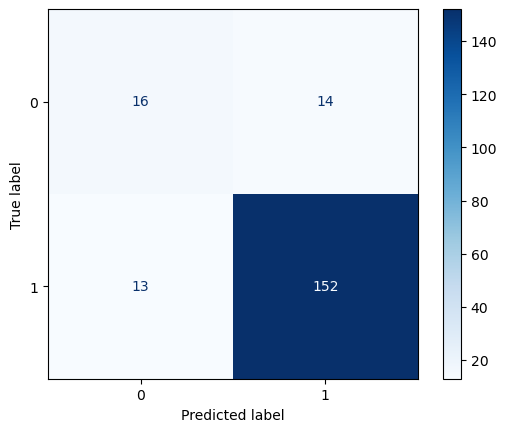

In [25]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, best_final_model_object.predict(X_test)))
ConfusionMatrixDisplay.from_estimator(best_final_model_object, X_test, y_test, cmap=plt.cm.Blues)
plt.show()

La **matriz de confusión** confirma la dificultad del modelo para clasificar la clase minoritaria (Clase 0), con un F1-score de 0.54, lo que reduce el F1-score macro global. La tasa de acierto (accuracy), en cambio, es alta (0.86) porque el modelo predice muy bien la clase mayoritaria (Clase 1, F1 = 0.92). 

Este escenario, con **pocos datos** y **fuerte desbalanceo** de los mismos (solo 30 instancias en la Clase 0), hace que los resultados sean especialmente sensibles a cómo se divide el conjunto original en entrenamiento y prueba. Aunque usamos validación cruzada sobre el conjunto de entrenamiento para ajustar y evaluar el modelo de forma robusta, la partición inicial del 30% para test se fija al principio y no se repite. Por tanto, si por azar ese 30% contiene ejemplos atípicos o poco representativos de la clase minoritaria, el rendimiento en test puede variar mucho de una ejecución a otra. Aunque en este caso no ocurre, lo normal es que el score en test baje.

De hecho, si ejecutáis la libreta con una semilla distinta (por ejemplo, `random_state=42`), veréis que el F1-score en test puede empeorar notablemente, aunque el procedimiento sea idéntico. Esto no indica un fallo del modelo, sino la alta incertidumbre inherente a evaluar con pocos datos desbalanceados. 

En situaciones como esta, una alternativa más rigurosa sería la **validación cruzada anidada** (nested cross-validation). [Aquí](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html#sphx-glr-auto-examples-model-selection-plot-nested-cross-validation-iris-py) tenéis más información.